# UCI HAR Dataset 기반 Depthwise Separable Conv 분류

### 결과 분석
```
Test accuracy: 93.96%
```
Depthwise Separable Conv 기반 모델은 UCI HAR 데이터셋에서 test accuracy 93.96% 이는 초기 Conv1D를 통해 입력 센서 신호를 64차원 feature channel로 확장한 뒤, Depthwise Separable Conv block을 통해 시간 방향의 활동 패턴을 효율적으로 학습했기 때문으로 해석된다.

반면 sitting과 standing의 차이가 큰 움직임 패턴보다는 자세 방향, 중력 성분, 센서 축의 미세한 차이에서 나타나지만 Depthwise Separable Conv는 채널별 시간 패턴 추출과 채널 결합을 분리하여 연산량을 줄이는 구조이기 때문에 이러한 미세한 채널 간 조합 차이를 강하게 반영하는 데 한계가 있을 수 있다.

따라서 sitting과 standing과 같은 유사한 정적 활동을 구분하는 데에는 추가적인 channel attention 또는 temporal attention 구조가 필요하다고 판단된다.

In [1]:
# 라이브러리 import
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, SeparableConv1D, BatchNormalization, ReLU, MaxPooling1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST  = "test/"

INPUT_SIGNAL_TYPES = [
    "body_acc_x_", "body_acc_y_", "body_acc_z_",
    "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
    "total_acc_x_", "total_acc_y_", "total_acc_z_"
]

LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

In [4]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []
    for signal_type_path in X_signals_paths:
        signal_data = []
        with open(signal_type_path, 'r') as file:
            for row in file:
                row = row.replace('  ', ' ').strip().split(' ')
                row = [np.float32(x) for x in row]
                signal_data.append(row)
        X_signals.append(signal_data)

    X_signals = np.array(X_signals)
    # (9, samples, 128) -> (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [5]:
# y 데이터 로드 함수
def load_y(y_path):
    y = []
    with open(y_path, 'r') as file:
        for row in file:
            y.append(int(row.strip()))
    y = np.array(y, dtype=np.int32)
    return y - 1  # 1~6 -> 0~5

In [6]:
# 데이터 로드
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test  = load_X(X_test_signals_paths)
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
y_test  = load_y(DATASET_PATH + TEST  + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:",  y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [7]:
# 데이터 표준화
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

In [8]:
# One-hot 인코딩
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot  = tf.keras.utils.to_categorical(y_test,  num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:",  y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


## Depthwise Separable Convolution

- 일반 Conv는 시간 패턴 추출과 채널 혼합을 **동시에** 수행

- Depthwise Separable Conv는 이 두 연산을 **완전히 분리**해서 순서대로 처리

---
### Depthwise Separable Conv1D = Depthwise Conv + Pointwise Conv

**Step 1 — Depthwise Conv (시간 패턴 추출)**
입력 (batch, time, C_in)

  → 채널마다 독립적으로 kernel 적용 (채널 간 혼합 없음)

출력 (batch, time, C_in)  ← 채널 수 그대로

파라미터 수 = kernel × C_in

**Step 2 — Pointwise Conv (채널 혼합)**
입력 (batch, time, C_in)

  → kernel_size=1 Conv로 채널 간 정보 합성

출력 (batch, time, C_out)

파라미터 수 = C_in × C_out

---

**파라미터 비교 (kernel=3, C_in=256, C_out=256)**

파라미터 수
- 일반 Conv1D: 3 × 256 × 256 = **196,608**
- Depthwise Separable: (3 × 256) + (256 × 256) = **66,304**

약 **66%** 절감  

In [9]:
# Depthwise Separable Conv Block 정의
# SeparableConv1D = Depthwise Conv + Pointwise Conv (1×1 Conv)
def dw_sep_block(x, filters, kernel_size=3, pool=True):
    # Depthwise Conv: 각 채널 독립적으로 시간 패턴 추출
    # Pointwise Conv: 채널 간 정보 혼합 (kernel_size=1 상당)
    x = SeparableConv1D(
        filters,
        kernel_size=kernel_size,
        padding='same',
        use_bias=False,
        depthwise_initializer='he_normal',
        pointwise_initializer='he_normal'
    )(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # 두 번째 Depthwise Separable Conv: 더 복잡한 특징 학습
    x = SeparableConv1D(
        filters,
        kernel_size=kernel_size,
        padding='same',
        use_bias=False,
        depthwise_initializer='he_normal',
        pointwise_initializer='he_normal'
    )(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

In [10]:
def build_dw_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = GaussianNoise(0.01)(inputs)

    # 단일 초기 Conv로 채널 확장
    x = Conv1D(64, kernel_size=5, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Depthwise Separable Conv Blocks
    x = dw_sep_block(x, filters=64,  kernel_size=3, pool=True)
    x = dw_sep_block(x, filters=128, kernel_size=3, pool=True)
    x = dw_sep_block(x, filters=128, kernel_size=3, pool=False)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [11]:
# 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 9)
num_classes = 6

model = build_dw_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 128, 9)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │      2,880 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d    │ (None, 128, 64)   │      4,288 │ re_lu[0][0]       │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_1  │ (None, 128, 64)   │      4,288 │ re_lu_1[0][0]     │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 64)    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_2  │ (None, 64, 128)   │      8,384 │ max_pooling1d[0]… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_3  │ (None, 64, 128)   │     16,768 │ re_lu_3[0][0]     │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 128)   │          0 │ re_lu_4[0][0]   

 Total params: 106,630 (416.52 KB)

 Trainable params: 105,222 (411.02 KB)

 Non-trainable params: 1,408 (5.50 KB)

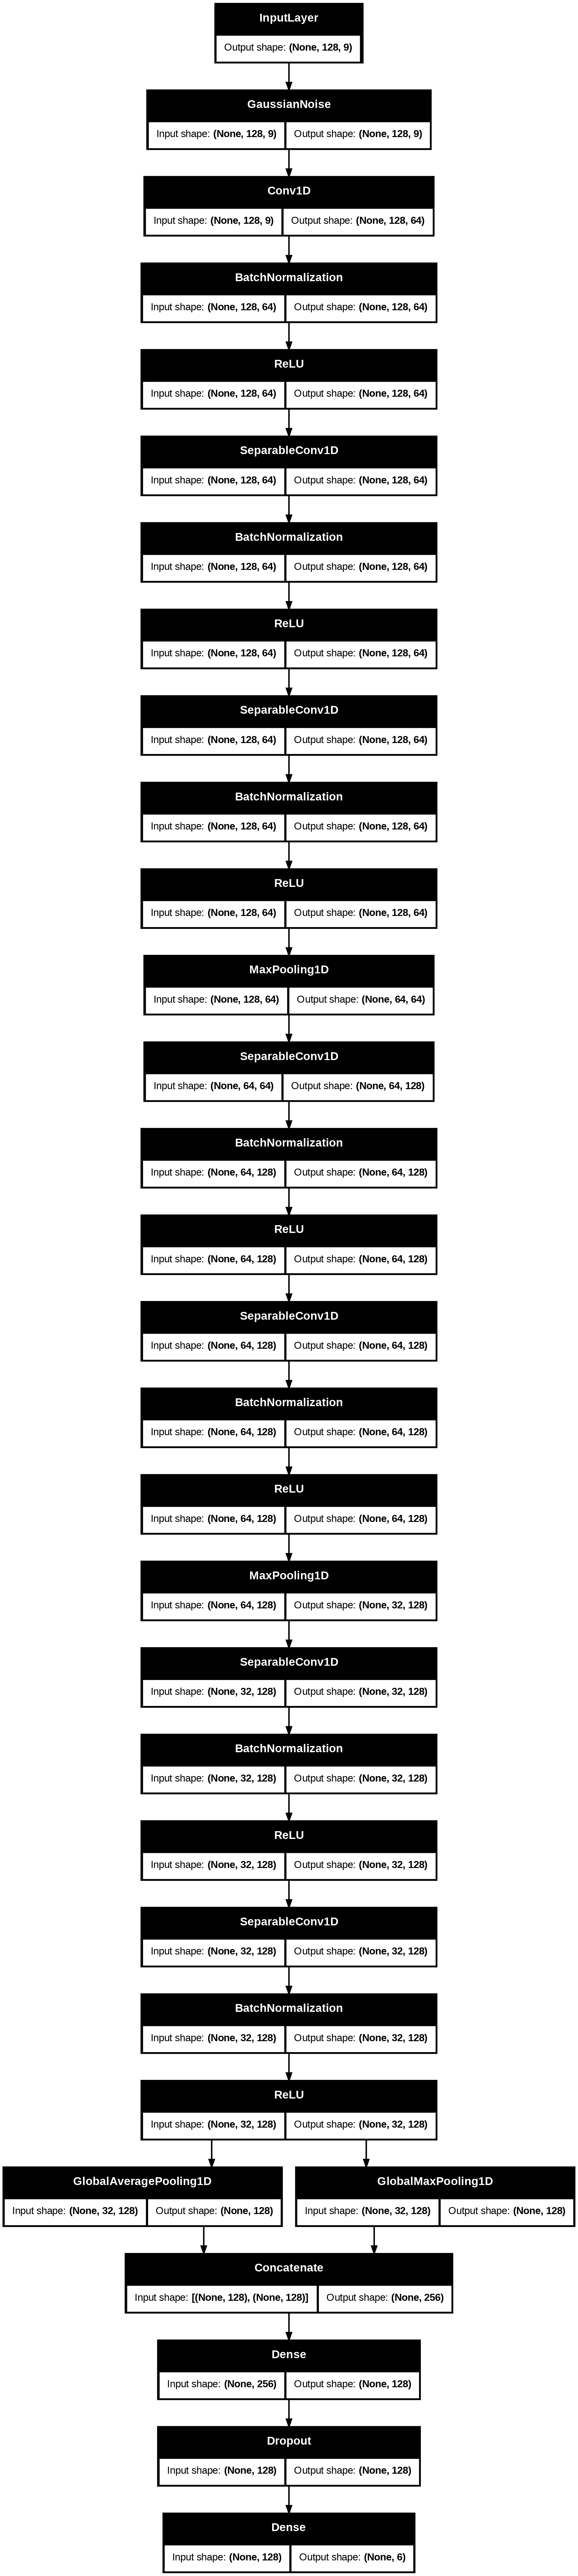

In [12]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [13]:
# Callback 설정
callbacks = [
    ModelCheckpoint(
        "UCI_HAR_DW_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=35,
        restore_best_weights=True,
        verbose=1
    )
]

In [14]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5313 - loss: 1.2970
Epoch 1: val_accuracy improved from None to 0.17947, saving model to UCI_HAR_DW_best.keras

Epoch 1: finished saving model to UCI_HAR_DW_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 188ms/step - accuracy: 0.7118 - loss: 0.8562 - val_accuracy: 0.1795 - val_loss: 1.7867 - learning_rate: 3.0000e-04
Epoch 2/200
88/92 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9118 - loss: 0.3629
Epoch 2: val_accuracy did not improve from 0.17947
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9269 - loss: 0.3240 - val_accuracy: 0.1795 - val_loss: 1.7939 - learning_rate: 3.0000e-04
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9434 - loss: 0.2769
Epoch 3: val_accuracy did not improve from 0.17947
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9486 - loss: 0.2668 - val_accuracy: 0.1795 - val_loss: 1.8285 - learning_rate: 3.0000e-04
Epoch 4/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc

In [15]:
model = tf.keras.models.load_model("UCI_HAR_DW_best.keras")

In [16]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test_onehot,  verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 95.47%
Training loss: 0.2310
Test accuracy: 93.96%
Test loss: 0.2832


In [17]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9940    0.9970       496
           1     0.9805    0.9597    0.9700       471
           2     0.9497    0.9881    0.9685       420
           3     0.8444    0.8513    0.8479       491
           4     0.8683    0.8553    0.8617       532
           5     0.9981    0.9981    0.9981       537

    accuracy                         0.9396      2947
   macro avg     0.9402    0.9411    0.9405      2947
weighted avg     0.9397    0.9396    0.9396      2947



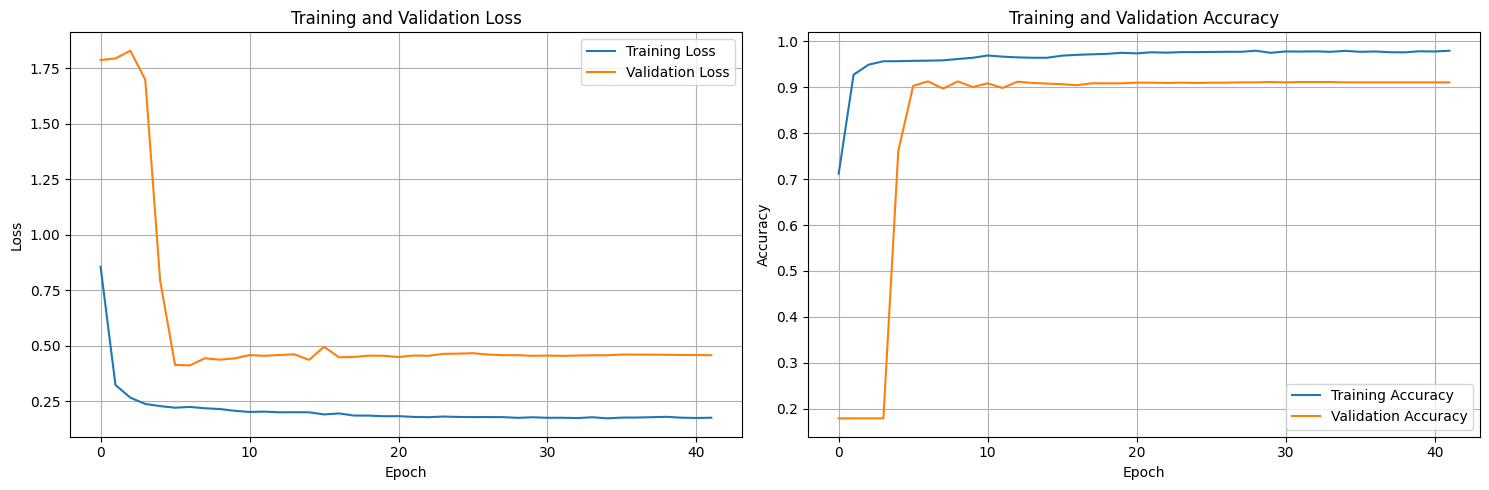

In [18]:
# 학습 곡선 시각화
train_loss_hist = history.history['loss']
val_loss_hist   = history.history['val_loss']
train_acc_hist  = history.history['accuracy']
val_acc_hist    = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Training Loss')
plt.plot(val_loss_hist,   label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Training Accuracy')
plt.plot(val_acc_hist,   label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

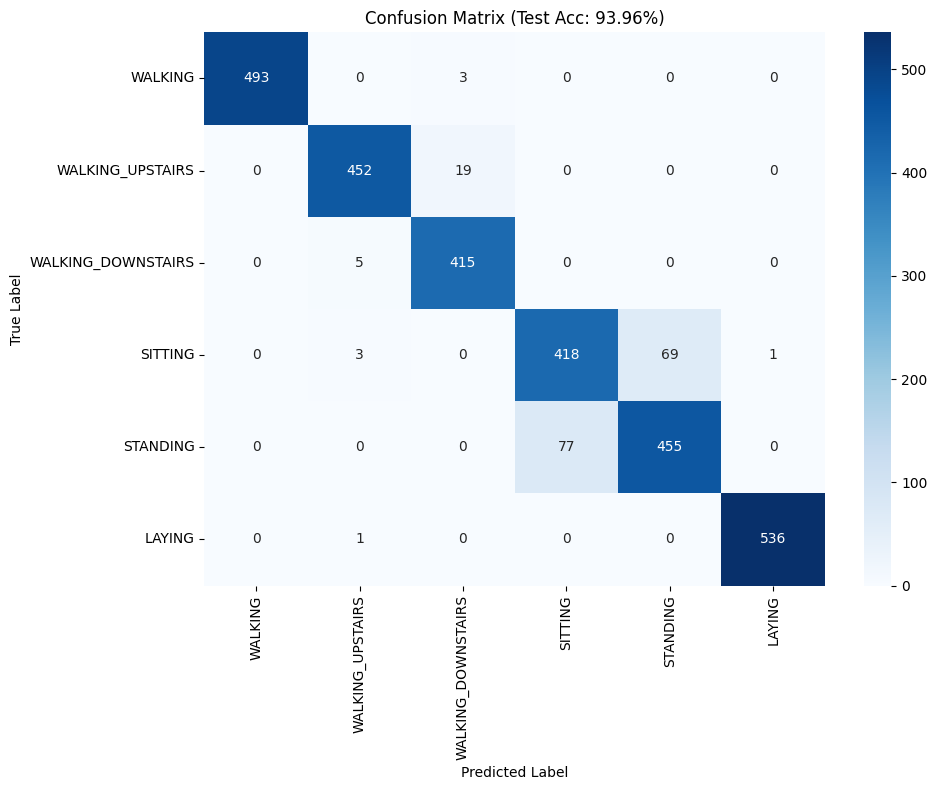

In [19]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()